# Phân Tích Cảm Xúc Đa Khía Cạnh (ABSA) - BiLSTM + PhoBert Embedding + Word Segmentations

## Cài đặt thư viện


In [1]:
!pip install -q py_vncorenlp underthesea pyvi gensim iterative-stratification seaborn scikit-learn transformers

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 80.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 53.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.7 MB/s eta 0:00:00


## Import thư viện


In [ ]:
import os
import gc
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoTokenizer, AutoModel

from pyvi import ViTokenizer
from underthesea import word_tokenize
import py_vncorenlp

import os
import py_vncorenlp
from pyvi import ViTokenizer
from underthesea import word_tokenize

warnings.filterwarnings('ignore')

# ==========================================
# 1. CẤU HÌNH & SEED
# ==========================================
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cuda.matmul.allow_tf32 = True

seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## Cấu hình


In [ ]:
# --- CẤU HÌNH BILSTM & PHOBERT ---
MAX_LENGTH = 160
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.2

# --- CẤU HÌNH HUẤN LUYỆN ---
EPOCHS = 8
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
USE_ASPECT_ATTENTION = True

ABSENT_CLASS = 3
SENTIMENT_CLASSES = [0, 1, 2]
ASPECT_COLS = ['as_content', 'as_physical', 'as_price', 'as_packaging', 'as_delivery', 'as_service']
LABEL_COLS = ['sentiment_llm', *ASPECT_COLS]

DATA_ROOT = Path('/kaggle/input/datasets/jyang10/tiki-cleaned-book-reviews')
if not DATA_ROOT.exists():
    DATA_ROOT = Path('.') # Fallback
TRAIN_PATH = DATA_ROOT / 'train_clean.json'
VAL_PATH = DATA_ROOT / 'val_clean.json'
TEST_PATH = DATA_ROOT / 'test_clean.json'



current_working_dir = os.getcwd() 
OUTPUT_ROOT = Path(current_working_dir) / 'absa_bilstm_phobert'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## CHUẨN BỊ WORD SEGMENTERS


In [ ]:
print("Đang khởi tạo các công cụ tách từ...")

# 2.1 VnCoreNLP - FIX TRIỆT ĐỂ LỖI JAVA
current_dir = os.path.abspath(os.getcwd())
VNCORENLP_DIR = os.path.join(current_dir, 'VnCoreNLP_Model')

# Tạo thư mục nếu chưa có
os.makedirs(VNCORENLP_DIR, exist_ok=True)

# Kiểm tra xem file jar đã tồn tại và đủ dung lượng chưa (tránh lỗi tải dở dang)
jar_path = os.path.join(VNCORENLP_DIR, 'VnCoreNLP-1.2.jar')
if not os.path.exists(jar_path) or os.path.getsize(jar_path) < 1000000: # File jar thường lớn hơn 1MB
    print(f"Đang tải model VnCoreNLP về {VNCORENLP_DIR}...")
    py_vncorenlp.download_model(save_dir=VNCORENLP_DIR)
else:
    print("VnCoreNLP model đã tồn tại, bỏ qua bước tải.")

# Khởi tạo RDRSegmenter
try:
    rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir=VNCORENLP_DIR)
    print("Khởi tạo VnCoreNLP thành công!")
except Exception as e:
    print(f"Lỗi khi khởi tạo VnCoreNLP: {e}")
    print("VUI LÒNG RESTART KERNEL VÀ CHẠY LẠI TỪ ĐẦU!")

def seg_vncorenlp(text):
    if not isinstance(text, str) or not text.strip(): return ""
    try:
        sentences = rdrsegmenter.word_segment(text)
        return " ".join(sentences)
    except Exception as e:
        print(f"[Lỗi JVM ngầm] Đã bắt được lỗi: {e}")
        return text

# 2.2 Underthesea
def seg_underthesea(text):
    if not isinstance(text, str) or not text.strip(): return ""
    return word_tokenize(text, format="text")

# 2.3 Pyvi
def seg_pyvi(text):
    if not isinstance(text, str) or not text.strip(): return ""
    return ViTokenizer.tokenize(text.lower())

# 2.4 Không dùng Segmenter 
def seg_none(text):
    if not isinstance(text, str) or not text.strip(): return ""
    # Chỉ loại bỏ khoảng trắng thừa ở hai đầu, giữ nguyên vẹn raw text
    return text.strip().lower() 

# ==========================================
# GOM VÀO DICTIONARY ĐỂ CHẠY VÒNG LẶP
# ==========================================
SEGMENTERS = {
    "No_Segmenter": seg_none, 
    "Pyvi": seg_pyvi,
    "Underthesea": seg_underthesea,
    "VnCoreNLP": seg_vncorenlp
}

Đang khởi tạo các công cụ tách từ...
Đang tải model VnCoreNLP về /kaggle/working/VnCoreNLP_Model...


--2026-04-05 07:19:47--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412703 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.2.jar’

     0K .......... .......... .......... .......... ..........  0% 12.0M 2s
    50K .......... .......... .......... .......... ..........  0% 25.2M 2s
   100K .......... .......... .......... .......... ..........  0% 20.6M 1s
   150K .......... .......... .......... .......... ..........  0% 40.5M 1s
   200K .......... .......... .......... .......... ..........  0% 76.7M 1s
   250K .......... .......... .......... .......... ..........  1% 21.8M 1s
   300K .......... .......... .......... .......... ..........  1% 73.2M 1s
   350K ..

2026-04-05 07:19:54 INFO  WordSegmenter:24 - Loading Word Segmentation model
Khởi tạo VnCoreNLP thành công!


In [5]:
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        # Bắt buộc phải reset_index để tránh lỗi ánh xạ DataLoader
        self.df = df.reset_index(drop=True) 
        self.tokenizer = tokenizer
        self.max_len = max_len
        
        # Tiền tính toán labels để tăng tốc I/O
        self.labels = np.array([
            self.df['sentiment_llm'].values,
            *[self.df[col].values for col in ASPECT_COLS]
        ]).T.astype(np.int64)

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df['text_seg'].iloc[idx])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, 
            return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

##  Load Tokenizer


In [6]:
import warnings
warnings.filterwarnings('ignore')
from transformers import AutoTokenizer

print("Đang nạp PhoBERT Tokenizer...")

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)
EMBEDDING_DIM = 768

print("Đã chuẩn bị xong dữ liệu và Tokenizer!")

Đang nạp PhoBERT Tokenizer...
Đã chuẩn bị xong dữ liệu và Tokenizer!


## Dataset & DataLoader


In [7]:
def load_and_prepare(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_json(path)

    title = df.get('review_title', df.get('title', pd.Series(['']*len(df)))).fillna('').astype(str).str.strip()
    body = df.get('content', df.get('text', pd.Series(['']*len(df)))).fillna('').astype(str).str.strip()

    df['text_full'] = title + " " + body
    
    df['sentiment_llm'] = pd.to_numeric(df['sentiment_llm'], errors='coerce')
    df = df.dropna(subset=['sentiment_llm'])
    df['sentiment_llm'] = df['sentiment_llm'].astype(int)
    df = df[df['sentiment_llm'].isin(SENTIMENT_CLASSES)]

    for col in ASPECT_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(ABSENT_CLASS).astype(int).clip(0, ABSENT_CLASS)

    return df[['text_full', *LABEL_COLS]].reset_index(drop=True)
    
raw_train_df = load_and_prepare(TRAIN_PATH)
raw_val_df = load_and_prepare(VAL_PATH)
raw_test_df = load_and_prepare(TEST_PATH)

print(f"Train: {raw_train_df.shape}, Val: {raw_val_df.shape}, Test: {raw_test_df.shape}")

Train: (9360, 8), Val: (2009, 8), Test: (2005, 8)


##  Kiến trúc mô hình


In [8]:
class SpatialDropout1D(nn.Module):
    def __init__(self, p):
        super(SpatialDropout1D, self).__init__()
        self.dropout = nn.Dropout2d(p)

    def forward(self, x):
        # x: (batch_size, seq_len, embed_dim)
        x = x.permute(0, 2, 1).unsqueeze(3)  # (batch, embed_dim, seq_len, 1)
        x = self.dropout(x)
        x = x.squeeze(3).permute(0, 2, 1)    # (batch, seq_len, embed_dim)
        return x

class PhoBERT_ABSABiLSTM(nn.Module):
    def __init__(self, hidden_dim, num_layers, dropout, num_aspects):
        super(PhoBERT_ABSABiLSTM, self).__init__()
        
        # ===== 1. ENCODER: PHOBERT =====
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base")
        embed_dim = self.phobert.config.hidden_size  # 768
        
        self.spatial_dropout = SpatialDropout1D(dropout)
        
        # ===== 2. BiLSTM =====
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        lstm_out_dim = hidden_dim * 2
        
        # ===== 3. Multi-head Self Attention =====
        self.num_heads = 4
        self.mha = nn.MultiheadAttention(
            embed_dim=lstm_out_dim,
            num_heads=self.num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # ===== 4. Attention Pooling =====
        self.attention_pool = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_dim // 2, 1)
        )
        
        self.feat_norm = nn.LayerNorm(lstm_out_dim * 3)
        cat_dim = lstm_out_dim * 3 
        
        # ===== 5. SENTIMENT BRANCH =====
        self.sent_proj = nn.Linear(cat_dim, hidden_dim)
        self.sent_decoupler = nn.Sequential(
            nn.Linear(cat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU()
        )
        self.sent_classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim, 3)
        )
        
        # ===== 6. ASPECT BRANCH =====
        self.asp_proj = nn.Linear(cat_dim, hidden_dim)
        self.asp_decoupler = nn.Sequential(
            nn.Linear(cat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU()
        )
        self.pres_classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim, num_aspects * 2)
        )
        self.asp_classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim, num_aspects * 3)
        )

        self.num_aspects = num_aspects

    def forward(self, input_ids, attention_mask):
        # ===== 1. PHOBERT ENCODING =====
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        embedded = outputs.last_hidden_state 
        embedded = self.spatial_dropout(embedded)
        
        # ===== 2. XỬ LÝ VARIABLE LENGTH =====
        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
        
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        packed_output, _ = self.lstm(packed_embedded)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output, batch_first=True
        )
        
        batch_size, max_len, _ = lstm_out.size()
        
        # ===== 3. TẠO MASK =====
        device = lstm_out.device
        mask = torch.arange(max_len).expand(batch_size, max_len).to(device) < lengths.unsqueeze(1).to(device)
        key_padding_mask = ~mask 
        
        # ===== 4. MULTI-HEAD ATTENTION =====
        attn_output, _ = self.mha(
            query=lstm_out,
            key=lstm_out,
            value=lstm_out,
            key_padding_mask=key_padding_mask
        )

        mask_expanded = mask.unsqueeze(-1)
        
        # ===== 5. ATTENTION POOLING =====
        attn_weights = self.attention_pool(attn_output)
        attn_weights = attn_weights.masked_fill(~mask_expanded, -1e9)
        attn_weights = torch.softmax(attn_weights, dim=1)
        mhsa_pool = torch.sum(attn_weights * attn_output, dim=1)
        
        # ===== 6. MAX POOLING =====
        max_pool = torch.max(
            lstm_out.masked_fill(~mask_expanded, -1e9),
            dim=1
        )[0]
        
        # ===== 7. AVERAGE POOLING =====
        mask_float = mask.float().unsqueeze(-1)
        avg_pool = torch.sum(lstm_out * mask_float, dim=1) / torch.sum(mask_float, dim=1).clamp(min=1e-9)
        
        # ===== 8. CONCAT FEATURE =====
        context_vector = torch.cat([mhsa_pool, max_pool, avg_pool], dim=-1)
        context_vector = self.feat_norm(context_vector)
        
        # ===== 9. SENTIMENT BRANCH =====
        residual_sent = self.sent_proj(context_vector)
        isolated_sent_context = self.sent_decoupler(context_vector) + residual_sent
        sent_logits = self.sent_classifier(isolated_sent_context)
        
        # ===== 10. ASPECT BRANCH =====
        residual_asp = self.asp_proj(context_vector)
        isolated_asp_context = self.asp_decoupler(context_vector) + residual_asp
            
        pres_logits = self.pres_classifier(isolated_asp_context).view(-1, self.num_aspects, 2)
        asp_logits = self.asp_classifier(isolated_asp_context).view(-1, self.num_aspects, 3)
        
        return sent_logits, pres_logits, asp_logits

# Khởi tạo mô hình
model = PhoBERT_ABSABiLSTM(
    hidden_dim=HIDDEN_DIM, 
    num_layers=NUM_LAYERS, 
    dropout=DROPOUT, 
    num_aspects=len(ASPECT_COLS)
).to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f"Kích hoạt Multi-GPU: Sử dụng {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Kích hoạt Multi-GPU: Sử dụng 2 GPUs!


##  Loss, metrics và trainer


In [9]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight 
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # 1. Tính CE Loss thuần để lấy đúng xác suất pt của class mục tiêu
        ce_loss_raw = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss_raw)
        
        # 2. Tính CE Loss có trọng số (Class Weights)
        ce_loss_weighted = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        
        # 3. Tính toán Focal Loss chính xác
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss_weighted
        
        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        return focal_loss
        
# --- TỰ ĐỘNG CÂN BẰNG MULTI-TASK LOSS BẰNG UNCERTAINTY ---
class AutomaticWeightedLoss(nn.Module):
    def __init__(self, num=3):
        super(AutomaticWeightedLoss, self).__init__()
        # Khởi tạo 3 tham số học được (cho Sent, Pres, Asp)
        self.params = nn.Parameter(torch.zeros(num, requires_grad=True))

    def forward(self, loss_sent, loss_pres, loss_asp):
        # Công thức tính theo Uncertainty Weighting (Kendall et al.)
        loss0 = loss_sent * torch.exp(-self.params[0]) + self.params[0]
        loss1 = loss_pres * torch.exp(-self.params[1]) + self.params[1]
        loss2 = loss_asp * torch.exp(-self.params[2]) + self.params[2]
        return loss0 + loss1 + loss2

def get_class_weights(labels_array, num_classes=3):
    weights = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=labels_array)
    smoothed_weights = np.sqrt(weights) 
    return torch.tensor(smoothed_weights, dtype=torch.float32)

# Hàm này giờ trả về 3 loss riêng lẻ, việc cộng gộp do AutomaticWeightedLoss lo
def compute_individual_losses(sent_logits, pres_logits, asp_logits, labels, sent_weights, pres_weights):
    true_sent = labels[:, 0]
    true_aspects = labels[:, 1:] 
    
    # 1. Loss Sentiment (Dùng Focal Loss)
    criterion_sent = FocalLoss(weight=sent_weights, gamma=2.0)
    loss_sent = criterion_sent(sent_logits, true_sent)
    
    # 2. Loss Presence
    true_pres = (true_aspects != ABSENT_CLASS).long()
    loss_pres = 0.0
    num_aspects = true_aspects.shape[1]
    
    for i in range(num_aspects):
        logits_i = pres_logits[:, i, :] 
        true_i = true_pres[:, i]        
        criterion_pres_i = nn.CrossEntropyLoss(weight=pres_weights[i])
        loss_pres += criterion_pres_i(logits_i, true_i)
    loss_pres = loss_pres / num_aspects 
    
    # 3. Loss Aspect Sentiment
    criterion_asp = nn.CrossEntropyLoss(label_smoothing=0.05)
    mask = true_aspects != ABSENT_CLASS 
    
    if mask.sum() > 0:
        asp_logits_flat = asp_logits.reshape(-1, 3)
        true_aspects_flat = true_aspects.reshape(-1)
        mask_flat = mask.reshape(-1)
        loss_asp = criterion_asp(asp_logits_flat[mask_flat], true_aspects_flat[mask_flat])
    else:
        loss_asp = torch.tensor(0.0, device=sent_logits.device, requires_grad=True)
        
    return loss_sent, loss_pres, loss_asp

def calculate_metrics(all_labels, all_preds):
    true_sent, true_asp = all_labels[:, 0], all_labels[:, 1:]
    pred_sent, pred_asp = all_preds[:, 0], all_preds[:, 1:]
    
    f1_sent = f1_score(true_sent, pred_sent, average='macro', zero_division=0)
    mask = true_asp != ABSENT_CLASS
    f1_asp_present = f1_score(true_asp[mask], pred_asp[mask], average='macro', zero_division=0) if mask.any() else 0.0
    f1_asp_all = f1_score(true_asp.flatten(), pred_asp.flatten(), labels=[0,1,2,3], average='macro', zero_division=0)
    
    f1_final = 0.5 * f1_sent + 0.5 * f1_asp_present
    return f1_sent, f1_asp_present, f1_asp_all, f1_final

## Training Loop


In [10]:
def run_experiment(segmenter_name, segment_func):

    seed_everything(SEED)
    
    print(f"\n{'='*60}")
    print(f"🚀 BẮT ĐẦU THỰC NGHIỆM VỚI SEGMENTER: {segmenter_name.upper()}")
    print(f"{'='*60}")
    
    # 1. Apply segmentation
    train_df = raw_train_df.copy()
    val_df = raw_val_df.copy()
    test_df = raw_test_df.copy()
    
    print(f"[{segmenter_name}] Đang tách từ tập Train...")
    train_df['text_seg'] = train_df['text_full'].apply(segment_func)
    print(f"[{segmenter_name}] Đang tách từ tập Val...")
    val_df['text_seg'] = val_df['text_full'].apply(segment_func)
    print(f"[{segmenter_name}] Đang tách từ tập Test...")
    test_df['text_seg'] = test_df['text_full'].apply(segment_func)
    
    # 2. Dataloaders
    train_loader = DataLoader(TextDataset(train_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(TextDataset(val_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2)
    test_loader = DataLoader(TextDataset(test_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2)

    # 3. Khởi tạo lại Model (Rất quan trọng để không bị dính weights cũ)
    model = PhoBERT_ABSABiLSTM(HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(ASPECT_COLS)).to(DEVICE)
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    awl = AutomaticWeightedLoss(num=3).to(DEVICE)

    # Cấu hình Optimizer
    phobert_params = list(model.module.phobert.parameters()) if hasattr(model, 'module') else list(model.phobert.parameters())
    custom_params = [p for n, p in model.named_parameters() if 'phobert' not in n]
    optimizer = torch.optim.AdamW([
        {'params': phobert_params, 'lr': 2e-5},           
        {'params': custom_params, 'lr': LEARNING_RATE},   
        {'params': awl.parameters(), 'weight_decay': 0.0, 'lr': LEARNING_RATE}
    ], weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    # Class weights
    dynamic_sent_weights = torch.tensor(np.sqrt(compute_class_weight('balanced', classes=np.array([0,1,2]), y=train_df['sentiment_llm'].values)), dtype=torch.float32).to(DEVICE)
    aspect_pres_weights = torch.tensor([np.sqrt(compute_class_weight('balanced', classes=np.array([0, 1]), y=(train_df[col].values != ABSENT_CLASS).astype(int))) for col in ASPECT_COLS], dtype=torch.float32).to(DEVICE)

    # 4. Training Loop
    best_val_f1 = 0.0
    best_model_path = OUTPUT_ROOT / f'best_model_{segmenter_name.lower()}.pt'

    for epoch in range(EPOCHS):
        model.train()
        awl.train()
        for batch in train_loader:
            input_ids, attention_mask, labels = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
            optimizer.zero_grad()
            sent_logits, pres_logits, asp_logits = model(input_ids, attention_mask)
            l_sent, l_pres, l_asp = compute_individual_losses(sent_logits, pres_logits, asp_logits, labels, dynamic_sent_weights, aspect_pres_weights)
            loss = awl(l_sent, l_pres, l_asp)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Validation
        model.eval()
        awl.eval()
        val_labels, val_preds = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids, attention_mask, labels = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
                sent_logits, pres_logits, asp_logits = model(input_ids, attention_mask)
                
                p_sent = sent_logits.argmax(dim=-1).cpu().numpy()
                p_pres = pres_logits.argmax(dim=-1).cpu().numpy()
                p_asp = np.where(p_pres == 0, ABSENT_CLASS, asp_logits.argmax(dim=-1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                val_preds.extend(np.column_stack((p_sent, p_asp)))

        # FIX LỖI UNPACK VARIABLES TẠI ĐÂY
        val_f1_sent, val_f1_asp, _, val_f1_final = calculate_metrics(np.array(val_labels), np.array(val_preds))
        scheduler.step(val_f1_final)
        print(f"[{segmenter_name}] Epoch {epoch+1}/{EPOCHS} - Val F1 Final: {val_f1_final:.4f} (Sent: {val_f1_sent:.4f}, Asp: {val_f1_asp:.4f})")

        if val_f1_final > best_val_f1:
            best_val_f1 = val_f1_final
            torch.save((model.module if hasattr(model, 'module') else model).state_dict(), best_model_path)

    #  Đánh giá Phase (Dùng model tốt nhất trên tập VAL)
    print(f"[{segmenter_name}] Đang đánh giá mô hình tốt nhất trên tập Val...")
    (model.module if hasattr(model, 'module') else model).load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    model.eval()
    
    final_val_labels, final_val_preds = [], []
    with torch.no_grad():
        # THAY ĐỔI TEST_LOADER THÀNH VAL_LOADER TẠI ĐÂY
        for batch in val_loader:
            input_ids, attention_mask, labels = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
            sent_logits, pres_logits, asp_logits = model(input_ids, attention_mask)
            p_sent = sent_logits.argmax(dim=-1).cpu().numpy()
            p_pres = pres_logits.argmax(dim=-1).cpu().numpy()
            p_asp = np.where(p_pres == 0, ABSENT_CLASS, asp_logits.argmax(dim=-1).cpu().numpy())
            final_val_labels.extend(labels.cpu().numpy())
            final_val_preds.extend(np.column_stack((p_sent, p_asp)))

    # FIX LỖI UNPACK VARIABLES 
    best_val_f1_sent, best_val_f1_asp, _, best_val_f1_final = calculate_metrics(np.array(final_val_labels), np.array(final_val_preds))
    
    # Giải phóng toàn bộ bộ nhớ GPU và RAM
    del model, optimizer, train_loader, val_loader, test_loader
    del awl, train_df, val_df, test_df
    torch.cuda.empty_cache()
    gc.collect()
    
    return {"F1_Overall_Sentiment": best_val_f1_sent, "F1_Mean_Aspects": best_val_f1_asp, "F1_Final": best_val_f1_final}

In [11]:
results = {}

for name, func in SEGMENTERS.items():
    results[name] = run_experiment(name, func)

print("\n" + "="*60)
print("BẢNG TỔNG HỢP SO SÁNH KẾT QUẢ 4 MÔ HÌNH ")
print("="*60)
comparison_df = pd.DataFrame(results).T
print(comparison_df.round(4).to_string())


🚀 BẮT ĐẦU THỰC NGHIỆM VỚI SEGMENTER: NO_SEGMENTER
[No_Segmenter] Đang tách từ tập Train...
[No_Segmenter] Đang tách từ tập Val...
[No_Segmenter] Đang tách từ tập Test...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[No_Segmenter] Epoch 1/8 - Val F1 Final: 0.6127 (Sent: 0.7926, Asp: 0.4328)
[No_Segmenter] Epoch 2/8 - Val F1 Final: 0.6309 (Sent: 0.7752, Asp: 0.4865)
[No_Segmenter] Epoch 3/8 - Val F1 Final: 0.6820 (Sent: 0.7976, Asp: 0.5664)
[No_Segmenter] Epoch 4/8 - Val F1 Final: 0.6775 (Sent: 0.7916, Asp: 0.5634)
[No_Segmenter] Epoch 5/8 - Val F1 Final: 0.7006 (Sent: 0.8241, Asp: 0.5772)
[No_Segmenter] Epoch 6/8 - Val F1 Final: 0.6819 (Sent: 0.7857, Asp: 0.5782)
[No_Segmenter] Epoch 7/8 - Val F1 Final: 0.7043 (Sent: 0.8197, Asp: 0.5888)
[No_Segmenter] Epoch 8/8 - Val F1 Final: 0.6958 (Sent: 0.8109, Asp: 0.5807)
[No_Segmenter] Đang đánh giá mô hình tốt nhất trên tập Val...

🚀 BẮT ĐẦU THỰC NGHIỆM VỚI SEGMENTER: PYVI
[Pyvi] Đang tách từ tập Train...
[Pyvi] Đang tách từ tập Val...
[Pyvi] Đang tách từ tập Test...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Underthesea] Epoch 1/8 - Val F1 Final: 0.6318 (Sent: 0.8132, Asp: 0.4505)
[Underthesea] Epoch 2/8 - Val F1 Final: 0.6547 (Sent: 0.8131, Asp: 0.4964)
[Underthesea] Epoch 3/8 - Val F1 Final: 0.6686 (Sent: 0.8061, Asp: 0.5311)
[Underthesea] Epoch 4/8 - Val F1 Final: 0.6968 (Sent: 0.8416, Asp: 0.5520)
[Underthesea] Epoch 5/8 - Val F1 Final: 0.6992 (Sent: 0.8186, Asp: 0.5799)
[Underthesea] Epoch 6/8 - Val F1 Final: 0.6977 (Sent: 0.8290, Asp: 0.5665)
[Underthesea] Epoch 7/8 - Val F1 Final: 0.7089 (Sent: 0.8343, Asp: 0.5835)
[Underthesea] Epoch 8/8 - Val F1 Final: 0.7081 (Sent: 0.8315, Asp: 0.5847)
[Underthesea] Đang đánh giá mô hình tốt nhất trên tập Val...

🚀 BẮT ĐẦU THỰC NGHIỆM VỚI SEGMENTER: VNCORENLP
[VnCoreNLP] Đang tách từ tập Train...
[VnCoreNLP] Đang tách từ tập Val...
[VnCoreNLP] Đang tách từ tập Test...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[VnCoreNLP] Epoch 1/8 - Val F1 Final: 0.6337 (Sent: 0.8137, Asp: 0.4537)
[VnCoreNLP] Epoch 2/8 - Val F1 Final: 0.6513 (Sent: 0.7915, Asp: 0.5110)
[VnCoreNLP] Epoch 3/8 - Val F1 Final: 0.6947 (Sent: 0.8208, Asp: 0.5686)
[VnCoreNLP] Epoch 4/8 - Val F1 Final: 0.7025 (Sent: 0.8380, Asp: 0.5669)
[VnCoreNLP] Epoch 5/8 - Val F1 Final: 0.7040 (Sent: 0.8290, Asp: 0.5790)
[VnCoreNLP] Epoch 6/8 - Val F1 Final: 0.7030 (Sent: 0.8131, Asp: 0.5929)
[VnCoreNLP] Epoch 7/8 - Val F1 Final: 0.7190 (Sent: 0.8441, Asp: 0.5940)
[VnCoreNLP] Epoch 8/8 - Val F1 Final: 0.7181 (Sent: 0.8435, Asp: 0.5928)
[VnCoreNLP] Đang đánh giá mô hình tốt nhất trên tập Val...

BẢNG TỔNG HỢP SO SÁNH KẾT QUẢ 4 MÔ HÌNH 
              F1_Overall_Sentiment  F1_Mean_Aspects  F1_Final
No_Segmenter                0.8197           0.5888    0.7043
Pyvi                        0.8413           0.5936    0.7174
Underthesea                 0.8343           0.5835    0.7089
VnCoreNLP                   0.8441           0.5940    0.7190


## Đánh giá



ĐÁNH GIÁ MÔ HÌNH BILSTM + PHOBERT TRÊN TẬP TEST
[*] Segmenter chiến thắng: VnCoreNLP (F1_Final: 0.7190)
[*] Đang tách từ tập Test bằng VnCoreNLP...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Đang load trọng số từ: /kaggle/working/absa_bilstm_phobert/best_model_vncorenlp.pt

=== BÁO CÁO TỔNG THỂ (OVERALL SENTIMENT) ===
              precision    recall  f1-score   support

         neg       0.94      0.94      0.94      1048
         neu       0.68      0.75      0.71       324
         pos       0.93      0.88      0.91       633

    accuracy                           0.89      2005
   macro avg       0.85      0.86      0.85      2005
weighted avg       0.90      0.89      0.89      2005


=== Báo Cáo Mean 6 ASPECTS (PRESENT ONLY) ===
              precision    recall  f1-score   support

         neg       0.87      0.84      0.85       805
         neu       0.72      0.61      0.66       410
         pos       0.94      0.86      0.90      1291

   micro avg       0.88      0.81      0.85      2506
   macro avg       0.84      0.77      0.80      2506
weighted avg       0.88      0.81      0.84      2506


=== TEST METRICS CHI TIẾT ===
eval_f1_sentiment: 0.8529
e

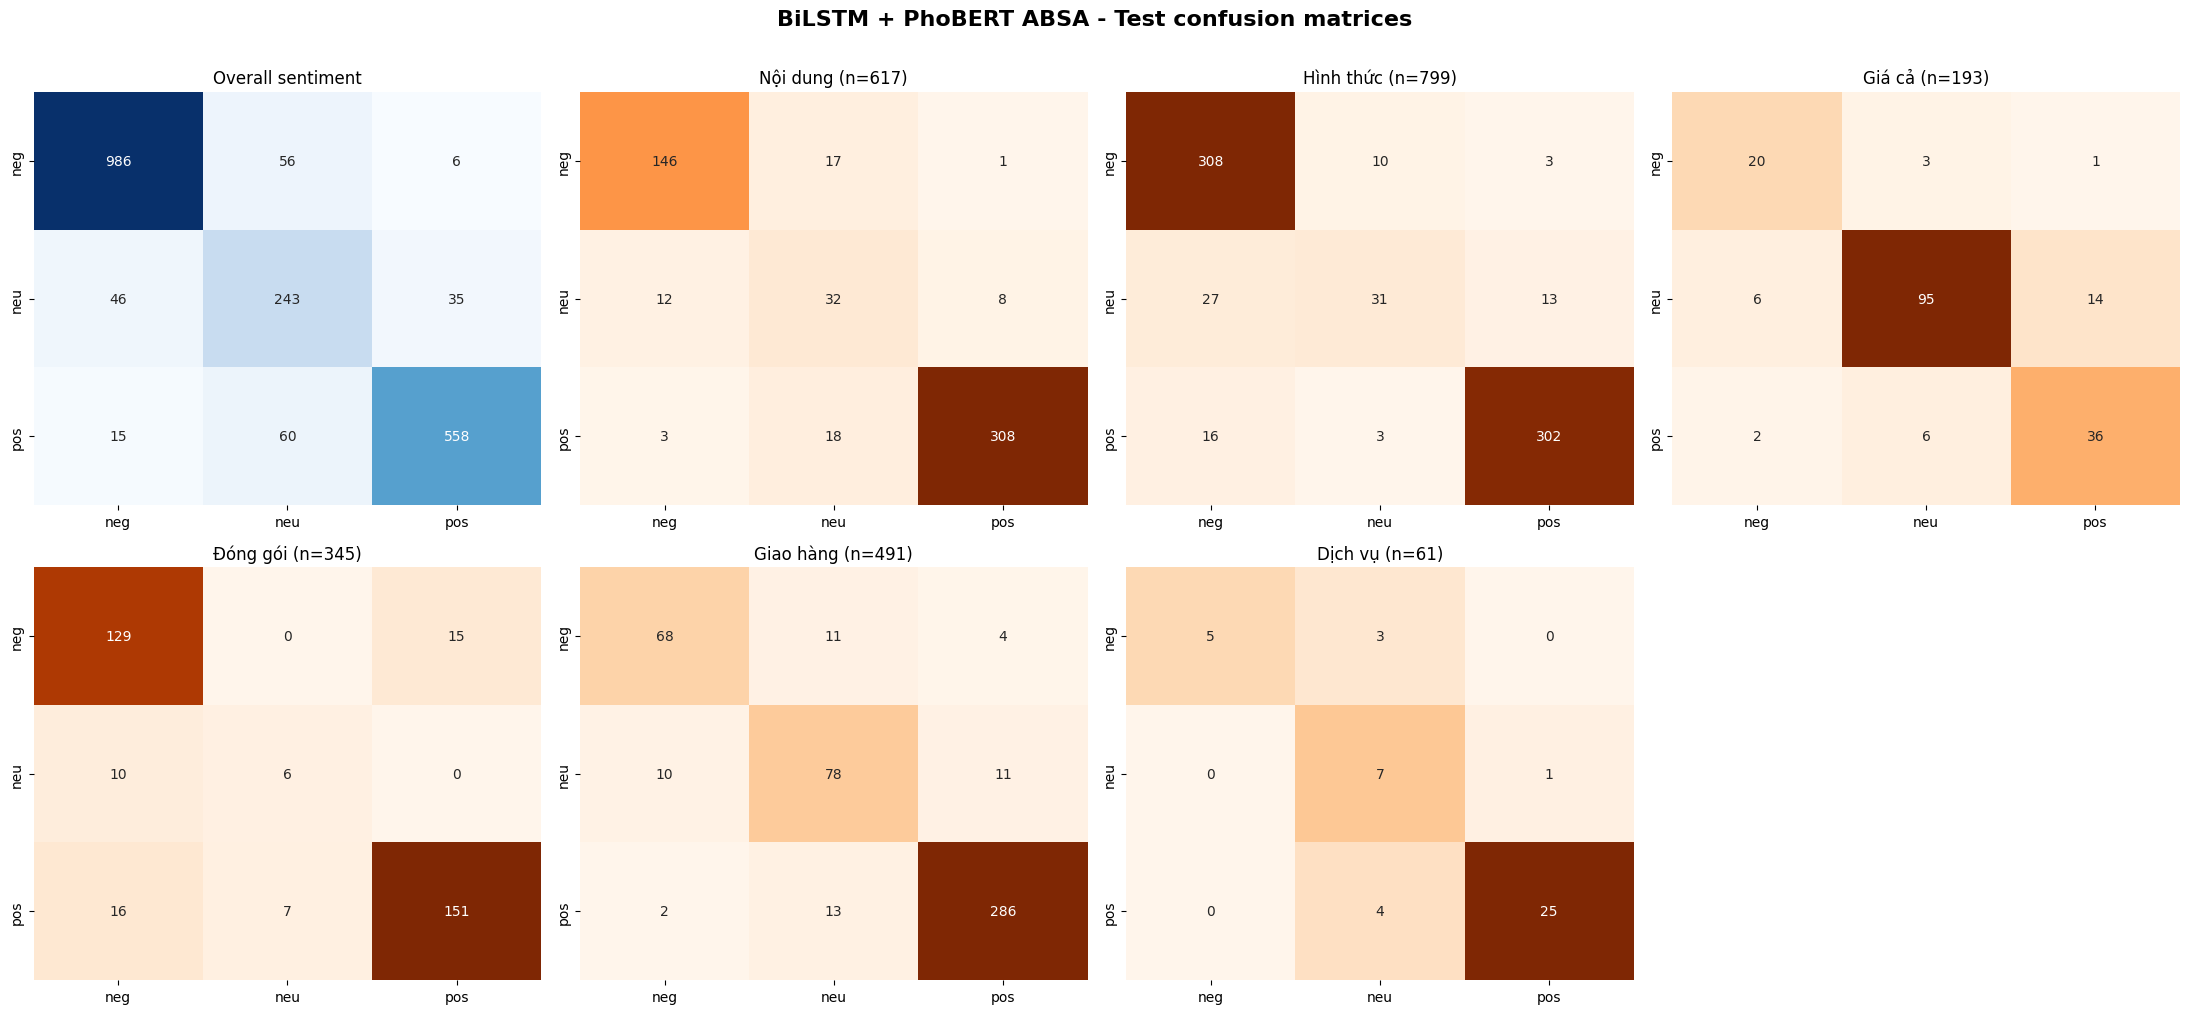

In [12]:
# Định nghĩa tên khía cạnh tiếng Việt để hiển thị cho đẹp
ASPECT_NAMES = ['Nội dung', 'Hình thức', 'Giá cả', 'Đóng gói', 'Giao hàng', 'Dịch vụ']
ASPECT_COLS = ['as_content', 'as_physical', 'as_price', 'as_packaging', 'as_delivery', 'as_service']
ABSENT_CLASS = 3

def plot_confusion_matrices(true_sentiment: np.ndarray, pred_sentiment: np.ndarray, true_aspects: np.ndarray, pred_aspects: np.ndarray) -> None:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()

    # Nhãn cảm xúc: 0 (tiêu cực), 1 (trung tính), 2 (tích cực)
    sent_cm = confusion_matrix(true_sentiment, pred_sentiment, labels=[0, 1, 2])
    sns.heatmap(sent_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'], ax=axes[0])
    axes[0].set_title('Overall sentiment')

    for idx, col in enumerate(ASPECT_COLS):
        ax = axes[idx + 1]
        # Bỏ qua các khía cạnh không xuất hiện (ABSENT_CLASS = 3) trong nhãn thực tế
        mask = true_aspects[:, idx] != ABSENT_CLASS
        if mask.sum() == 0:
            ax.set_visible(False)
            continue

        cm = confusion_matrix(true_aspects[:, idx][mask], pred_aspects[:, idx][mask], labels=[0, 1, 2])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
                    xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'], ax=ax)
        ax.set_title(f'{ASPECT_NAMES[idx]} (n={mask.sum()})')

    # Ẩn ô cuối cùng nếu dư
    if len(axes) > 7:
        axes[7].set_visible(False)

    plt.suptitle('BiLSTM + PhoBERT ABSA - Test confusion matrices', y=1.01, fontweight='bold', fontsize=16)
    plt.tight_layout()

    # Lưu ảnh ma trận nhầm lẫn
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    plt.savefig(OUTPUT_ROOT / 'confusion_matrix_test.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# THỰC THI ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
print("\n" + "="*60)
print("ĐÁNH GIÁ MÔ HÌNH BILSTM + PHOBERT TRÊN TẬP TEST")
print("="*60)

# 1. TÌM SEGMENTER VÀ MÔ HÌNH TỐT NHẤT
best_segmenter_name = max(results, key=lambda k: results[k]['F1_Final'])
print(f"[*] Segmenter chiến thắng: {best_segmenter_name} (F1_Final: {results[best_segmenter_name]['F1_Final']:.4f})")

# 2. TIỀN XỬ LÝ TẬP TEST BẰNG SEGMENTER TỐT NHẤT
best_segment_func = SEGMENTERS[best_segmenter_name]
test_df = raw_test_df.copy()
print(f"[*] Đang tách từ tập Test bằng {best_segmenter_name}...")
test_df['text_seg'] = test_df['text_full'].apply(best_segment_func)

# 3. KHỞI TẠO DATALOADER
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)
test_ldr = DataLoader(TextDataset(test_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=2)

# 4. KHỞI TẠO LẠI CẤU TRÚC MÔ HÌNH VÀ LOAD TRỌNG SỐ
model = PhoBERT_ABSABiLSTM(HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(ASPECT_COLS)).to(DEVICE)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

best_model_path = OUTPUT_ROOT / f'best_model_{best_segmenter_name.lower()}.pt'
print(f"[*] Đang load trọng số từ: {best_model_path}")
state_dict = torch.load(best_model_path, map_location=DEVICE)

if hasattr(model, 'module'):
    model.module.load_state_dict(state_dict)
else:
    model.load_state_dict(state_dict)

model.eval()

# 5. SUY LUẬN (INFERENCE)
true_sentiment, pred_sentiment = [], []
true_aspects, pred_aspects = [], []

start_time = time.time()
num_steps = len(test_ldr)
num_samples = len(test_df)

with torch.no_grad():
    for batch in test_ldr:  
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        # Lấy Logits từ mô hình
        sent_logits, pres_logits, asp_logits = model(input_ids, attention_mask)
        
        # Lấy nhãn dự đoán bằng argmax
        p_sent = sent_logits.argmax(dim=-1).cpu().numpy()
        p_pres = pres_logits.argmax(dim=-1).cpu().numpy()
        p_asp_sent = asp_logits.argmax(dim=-1).cpu().numpy()

        # Logic ghép nhãn: Nếu presence = 0 (không xuất hiện) -> gán nhãn ABSENT_CLASS (3)
        p_asp = np.where(p_pres == 0, ABSENT_CLASS, p_asp_sent)

        # Lưu trữ kết quả
        lbls_cpu = labels.cpu().numpy()
        true_sentiment.extend(lbls_cpu[:, 0])
        pred_sentiment.extend(p_sent)
        true_aspects.extend(lbls_cpu[:, 1:])
        pred_aspects.extend(p_asp)

# Tính toán các chỉ số về tốc độ suy luận
eval_runtime = time.time() - start_time
eval_samples_per_second = num_samples / eval_runtime
eval_steps_per_second = num_steps / eval_runtime

# Chuyển đổi sang Numpy Array
true_sentiment = np.array(true_sentiment)
pred_sentiment = np.array(pred_sentiment)
true_aspects = np.array(true_aspects)
pred_aspects = np.array(pred_aspects)

# BÁO CÁO TRUNG BÌNH TOÀN BỘ ASPECT (present only)
all_true, all_pred = [], []
for idx in range(len(ASPECT_COLS)):
    t_asp = true_aspects[:, idx]
    p_asp = pred_aspects[:, idx]
    mask = t_asp != ABSENT_CLASS  # chỉ lấy các aspect có xuất hiện
    if mask.sum() == 0:
        continue
    all_true.extend(t_asp[mask])
    all_pred.extend(p_asp[mask])

all_true = np.array(all_true)
all_pred = np.array(all_pred)

# TÍNH TOÁN CÁC CHỈ SỐ METRICS CHO DICTIONARY
eval_f1_sentiment = f1_score(true_sentiment, pred_sentiment, average='macro', labels=[0, 1, 2], zero_division=0)
eval_accuracy = accuracy_score(true_sentiment, pred_sentiment)
eval_f1_aspect_present = f1_score(all_true, all_pred, average='macro', labels=[0, 1, 2], zero_division=0) if len(all_true) > 0 else 0.0
eval_f1_aspect_all = f1_score(true_aspects.flatten(), pred_aspects.flatten(), average='macro', zero_division=0)
eval_f1_combined = (eval_f1_sentiment + eval_f1_aspect_present) / 2

# Tính F1 Macro cho từng khía cạnh riêng biệt
aspect_f1_dict = {}
for idx, col in enumerate(ASPECT_COLS):
    t_asp = true_aspects[:, idx]
    p_asp = pred_aspects[:, idx]
    mask = t_asp != ABSENT_CLASS
    if mask.sum() > 0:
        aspect_f1_dict[f'eval_f1_{col}'] = f1_score(t_asp[mask], p_asp[mask], average='macro', labels=[0, 1, 2], zero_division=0)
    else:
        aspect_f1_dict[f'eval_f1_{col}'] = 0.0

# THIẾT LẬP TỪ ĐIỂN CHỨA TEST METRICS
test_metrics = {
    'eval_f1_sentiment': eval_f1_sentiment,
    'eval_f1_aspect_all': eval_f1_aspect_all,
    'eval_f1_aspect_present': eval_f1_aspect_present,
    'eval_f1_combined': eval_f1_combined,
    'eval_accuracy': eval_accuracy,
    **aspect_f1_dict,
    'eval_runtime': eval_runtime,
    'eval_samples_per_second': eval_samples_per_second,
    'eval_steps_per_second': eval_steps_per_second
}

# IN RA BÁO CÁO VÀ TEST METRICS
print('\n=========================================')
print('=== BÁO CÁO TỔNG THỂ (OVERALL SENTIMENT) ===')
print('=========================================')
print(classification_report(true_sentiment, pred_sentiment, labels=[0, 1, 2], target_names=['neg', 'neu', 'pos'], zero_division=0))

print('\n=========================================')
print('=== Báo Cáo Mean 6 ASPECTS (PRESENT ONLY) ===')
print('=========================================')
print(classification_report(all_true, all_pred, labels=[0, 1, 2], target_names=['neg', 'neu', 'pos'], zero_division=0))

print('\n=========================================')
print('=== TEST METRICS CHI TIẾT ===')
print('=========================================')
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

# Vẽ đồ thị ma trận nhầm lẫn
plot_confusion_matrices(true_sentiment, pred_sentiment, true_aspects, pred_aspects)